In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import html as html_lib
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
sns.set_style('darkgrid')
sns.set_palette('husl')

In [2]:
USERS_PATH = r"d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Users.csv"
POSTS_PATH = r"d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Posts_Corrupted.csv"
OUT_USERS  = r"d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Users_Cleaned.csv"
OUT_POSTS  = r"d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Posts_Cleaned.csv"



In [3]:
df_users_raw = pd.read_csv(USERS_PATH)
print(f"Users  shape : {df_users_raw.shape}")
display(df_users_raw.head(3))

df_posts_raw = pd.read_csv(
    POSTS_PATH,
    engine='python',
    on_bad_lines='warn',
    quotechar='"',
    skipinitialspace=True
)
print(f"\nPosts  shape : {df_posts_raw.shape}")
display(df_posts_raw.head(3))


Users  shape : (1500, 5)


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842



Posts  shape : (12360, 8)


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,"Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fash...",25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,"My one month review of Pepsi Crystal Pepsi: Highly recommend. #Premium, #Fashion Would love to g...",1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Exceeded my expectations. Confused about #Beauty Rea...,2025-04-13T20:12:18,NaN,1410,839


In [6]:

print("------  USERS DATASET — INSPECTION   -----")

print(f"\nShape : {df_users_raw.shape}")
print(f"\nDtypes:\n{df_users_raw.dtypes}")
print(f"\nMissing Values:\n{df_users_raw.isnull().sum()}")
print(f"\nFull-row duplicates  : {df_users_raw.duplicated().sum()}")
print(f"Duplicate user_ids   : {df_users_raw['user_id'].duplicated().sum()}")
print("\n----Stats:---")
display(df_users_raw.describe())


------  USERS DATASET — INSPECTION   -----

Shape : (1500, 5)

Dtypes:
user_id              str
location             str
language             str
account_created      str
follower_count     int64
dtype: object

Missing Values:
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64

Full-row duplicates  : 0
Duplicate user_ids   : 0

----Stats:---


,follower_count
count,1500.000000
mean,24964.019333
std,14185.477457
min,109.000000
25%,12771.750000
50%,24741.500000
75%,37097.250000
max,49944.000000


In [7]:

print(" ----- POSTS DATASET — INSPECTION  -----")
df_posts_raw.info()
print()
print(f"{'Column':<22} {'NaN':>6}  {'NULL str':>9}  {'Total':>7}  {'%':>6}")
print("-" * 55)
for col in df_posts_raw.columns:
    nan_c  = df_posts_raw[col].isnull().sum()
    null_c = (df_posts_raw[col].astype(str).str.strip().str.upper() == 'NULL').sum()
    tot    = nan_c + null_c
    pct    = tot / len(df_posts_raw) * 100
    print(f"{col:<22} {nan_c:>6}  {null_c:>9}  {tot:>7}  {pct:>5.1f}%")


 ----- POSTS DATASET — INSPECTION  -----
<class 'pandas.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  str    
 1   user_id       12360 non-null  str    
 2   platform      10514 non-null  str    
 3   text_content  10614 non-null  str    
 4   timestamp     12360 non-null  str    
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 772.6 KB

Column                    NaN   NULL str    Total       %
-------------------------------------------------------
post_id                     0          0        0    0.0%
user_id                     0          0        0    0.0%
platform                 1846          0     1846   14.9%
text_content             1746         24     1770   14.3%
timestamp                

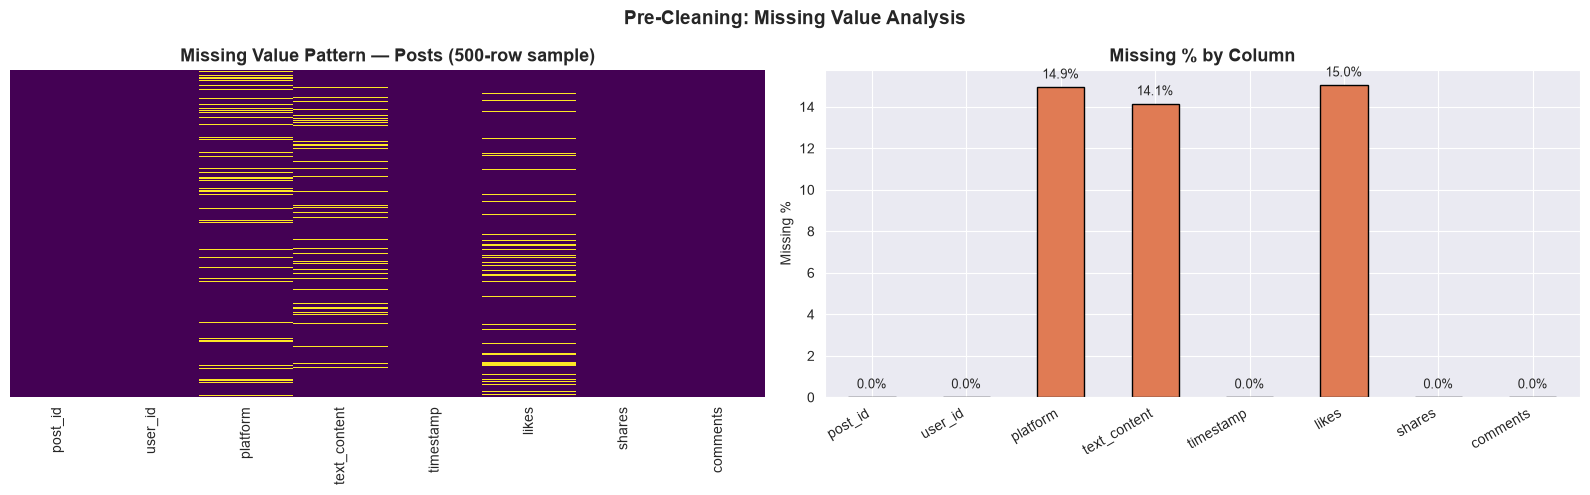

In [8]:
df_viz = df_posts_raw.replace(['NULL', 'null', 'None', ''], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_idx = np.random.choice(len(df_viz), min(500, len(df_viz)), replace=False)
sns.heatmap(df_viz.iloc[sample_idx].isnull(),
            yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Value Pattern — Posts (500-row sample)')

miss_pct = df_viz.isnull().sum() / len(df_viz) * 100
miss_pct.plot(kind='bar', ax=axes[1], color='#E07B54', edgecolor='black')
axes[1].set_title('Missing % by Column')
axes[1].set_ylabel('Missing %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
for bar, val in zip(axes[1].patches, miss_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Pre-Cleaning: Missing Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_01_missing_values.png", dpi=150, bbox_inches='tight')
plt.show()


In [9]:
df_users = df_users_raw.copy()

before = len(df_users)
df_users = df_users.drop_duplicates(subset='user_id', keep='first')
print(f"[STEP 1] Duplicates removed : {before - len(df_users)}")

df_users['account_created'] = pd.to_datetime(df_users['account_created'], errors='coerce')
print(f"[STEP 2] Unparseable dates  : {df_users['account_created'].isnull().sum()}")

print(f"[STEP 3] Missing values:\n{df_users.isnull().sum()}")

Q1 = df_users['follower_count'].quantile(0.25)
Q3 = df_users['follower_count'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_users[(df_users['follower_count'] < lower) | (df_users['follower_count'] > upper)]
print(f"[STEP 4] Follower count range: [{df_users['follower_count'].min()}, {df_users['follower_count'].max()}]")
print(f"         IQR bounds: [{lower:.0f}, {upper:.0f}]")
print(f"         Stat outlier rows (kept): {len(outliers)}")

print(f"\nUsers cleaned. Shape: {df_users.shape}")
display(df_users.head(3))


[STEP 1] Duplicates removed : 0
[STEP 2] Unparseable dates  : 0
[STEP 3] Missing values:
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64
[STEP 4] Follower count range: [109, 49944]
         IQR bounds: [-23716, 73586]
         Stat outlier rows (kept): 0

Users cleaned. Shape: (1500, 5)


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842


In [10]:

df_posts = df_posts_raw.copy()

NULL_STRINGS = ['NULL', 'null', 'None', 'none', 'NaN', 'nan', '', ' ']
for col in df_posts.columns:
    df_posts[col] = df_posts[col].replace(NULL_STRINGS, np.nan)

print("[STEP 1] NULL strings → np.nan | Missing counts:")
print(df_posts.isnull().sum())


[STEP 1] NULL strings → np.nan | Missing counts:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64


In [11]:

ENCODING_FIXES = {
    'Ã©': 'é', 'Ã¨': 'è', 'Ã ': 'à', 'Ã¢': 'â',
    'Ã®': 'î', 'Ã´': 'ô', 'Ã»': 'û', 'Ã§': 'ç',
    'Ã«': 'ë', 'Ã¯': 'ï', 'Ã¶': 'ö', 'Ã¼': 'ü',
    'â€™': "'", 'â€œ': '"', 'â€': '"', 'â€"': '–',
}

def fix_encoding(text):
    if pd.isna(text): return text
    for bad, good in ENCODING_FIXES.items():
        text = str(text).replace(bad, good)
    return text

def clean_html(text):
    if pd.isna(text): return text
    text = str(text)
    text = html_lib.unescape(text)            
    text = re.sub(r'<[^>]+>', ' ', text)      
    text = re.sub(r'\s+', ' ', text).strip()  
    return text

def collapse_newlines(text):
    if pd.isna(text): return text
    return re.sub(r'[\n\r]+', ' ', str(text)).strip()

df_posts['text_content'] = (
    df_posts['text_content']
    .apply(collapse_newlines)
    .apply(fix_encoding)
    .apply(clean_html)
)
df_posts['platform'] = df_posts['platform'].apply(fix_encoding)

print("[STEP 2-4] Encoding + HTML + newline fixes applied.")
sample = df_posts['text_content'].dropna().iloc[0]
print(f"\nSample cleaned text:\n  {sample}")


[STEP 2-4] Encoding + HTML + newline fixes applied.

Sample cleaned text:
  Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fashion&


In [12]:

def parse_ts(ts):
    if pd.isna(ts): return pd.NaT
    ts = str(ts).strip()

    if re.fullmatch(r'\d{10}', ts):
        try: return pd.Timestamp(int(ts), unit='s', tz='UTC')
        except: return pd.NaT

    if 'T' in ts:
        try:
            p = pd.Timestamp(ts)
            return p.tz_localize('UTC') if p.tzinfo is None else p.tz_convert('UTC')
        except: return pd.NaT

    if re.fullmatch(r'\d{4}-\d{2}-\d{2}', ts):
        try: return pd.Timestamp(ts, tz='UTC')
        except: return pd.NaT

    m = re.fullmatch(r'(\d{1,2})-(\d{1,2})-(\d{4})', ts)
    if m:
        p1, p2, yr = int(m.group(1)), int(m.group(2)), int(m.group(3))
        try: return pd.Timestamp(year=yr, month=p2, day=p1, tz='UTC')
        except:
            try: return pd.Timestamp(year=yr, month=p1, day=p2, tz='UTC')
            except: return pd.NaT
    return pd.NaT

df_posts['timestamp'] = df_posts['timestamp'].apply(parse_ts)

ok  = df_posts['timestamp'].notna().sum()
bad = df_posts['timestamp'].isna().sum()
print(f"[STEP 5] Timestamps parsed  : {ok} / {len(df_posts)} ({ok/len(df_posts)*100:.1f}%)")
print(f"         Unparseable (NaT)  : {bad}")
print(f"         Date range         : {df_posts['timestamp'].min()} → {df_posts['timestamp'].max()}")


[STEP 5] Timestamps parsed  : 12360 / 12360 (100.0%)
         Unparseable (NaT)  : 0
         Date range         : 2024-05-01 00:00:00+00:00 → 2025-04-30 21:57:10+00:00


In [13]:


for col in ['likes', 'shares', 'comments']:
    df_posts[col] = pd.to_numeric(df_posts[col], errors='coerce')

neg_mask = df_posts['likes'] < 0
print(f"[STEP 6] Negative likes → NaN : {neg_mask.sum()} rows")
df_posts.loc[neg_mask, 'likes'] = np.nan

for col in ['likes', 'shares', 'comments']:
    df_posts[col] = df_posts[col].astype('Int64')

for col in ['likes', 'shares', 'comments']:
    print(f"         {col:<10}: min={df_posts[col].min()}, max={df_posts[col].max()}, NaN={df_posts[col].isnull().sum()}")


[STEP 6] Negative likes → NaN : 525 rows
         likes     : min=0, max=5000, NaN=2383
         shares    : min=0, max=2000, NaN=0
         comments  : min=0, max=1000, NaN=0


In [14]:
VALID_PLATFORMS = {'Twitter', 'Instagram', 'Facebook', 'Reddit', 'YouTube'}

df_posts['platform'] = df_posts['platform'].str.strip()

platform_map = {
    'twitter':'Twitter','instagram':'Instagram',
    'facebook':'Facebook','reddit':'Reddit','youtube':'YouTube'
}
df_posts['platform'] = df_posts['platform'].replace(platform_map)

unexpected = df_posts[~df_posts['platform'].isin(VALID_PLATFORMS) & df_posts['platform'].notna()]
print(f"[STEP 7] Unexpected platform values: {unexpected['platform'].unique()}")
print(f"         Platform value counts:")
print(df_posts['platform'].value_counts(dropna=False).to_string())


[STEP 7] Unexpected platform values: <StringArray>
[]
Length: 0, dtype: str
         Platform value counts:
platform
YouTube      2136
Facebook     2135
Twitter      2119
Reddit       2086
Instagram    2038
NaN          1846


In [16]:

print(" ----- CLEANING SUMMARY — POSTS DATASET  ----")
print(f"  Original rows    : {len(df_posts_raw)}")
print(f"  Cleaned rows     : {len(df_posts)}  ← no rows dropped")
print(f"  Original columns : {df_posts_raw.shape[1]}")
print(f"  Cleaned columns  : {df_posts.shape[1]}")
print()
print("Remaining NaN values after cleaning:")
print(df_posts.isnull().sum().to_string())
print()
print("Data types:")
print(df_posts.dtypes.to_string())
display(df_posts.head(5))


 ----- CLEANING SUMMARY — POSTS DATASET  ----
  Original rows    : 12360
  Cleaned rows     : 12360  ← no rows dropped
  Original columns : 8
  Cleaned columns  : 8

Remaining NaN values after cleaning:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           2383
shares             0
comments           0

Data types:
post_id                         str
user_id                         str
platform                        str
text_content                    str
timestamp       datetime64[us, UTC]
likes                         Int64
shares                        Int64
comments                      Int64


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,"Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fash...",2024-09-25 00:00:00+00:00,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,"My one month review of Pepsi Crystal Pepsi: Highly recommend. #Premium, #Fashion Would love to g...",2024-08-01 16:14:00+00:00,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Exceeded my expectations. Confused about #Beauty Rea...,2025-04-13 20:12:18+00:00,<NA>,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,"Comparing Pepsi Crystal Pepsi to the competition. Best purchase ever. #Promo, #NewRelease Curiou...",2024-09-10 00:00:00+00:00,167,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,"My one week review of Coca-Cola Diet Coke: Best purchase ever. #BestValue, #Reviews Would love t...",2024-05-31 00:00:00+00:00,4749,152,630


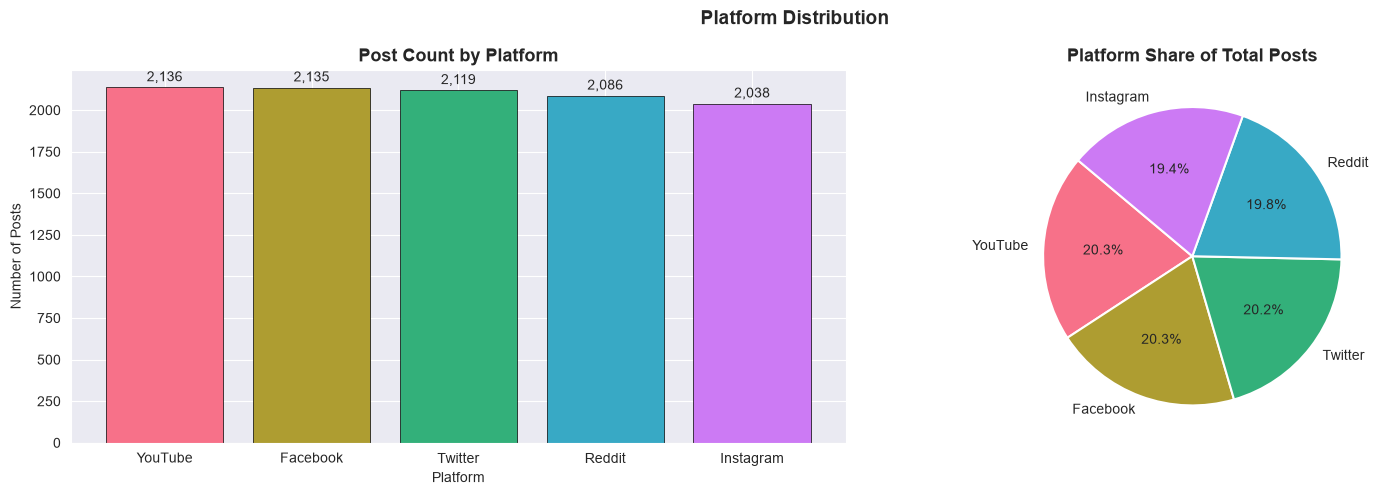

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

platform_counts = df_posts['platform'].value_counts()
colors = sns.color_palette('husl', len(platform_counts))

bars = axes[0].bar(platform_counts.index, platform_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Post Count by Platform')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Number of Posts')
for bar, val in zip(bars, platform_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[1].pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Platform Share of Total Posts')

plt.suptitle('Platform Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_02_platform_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


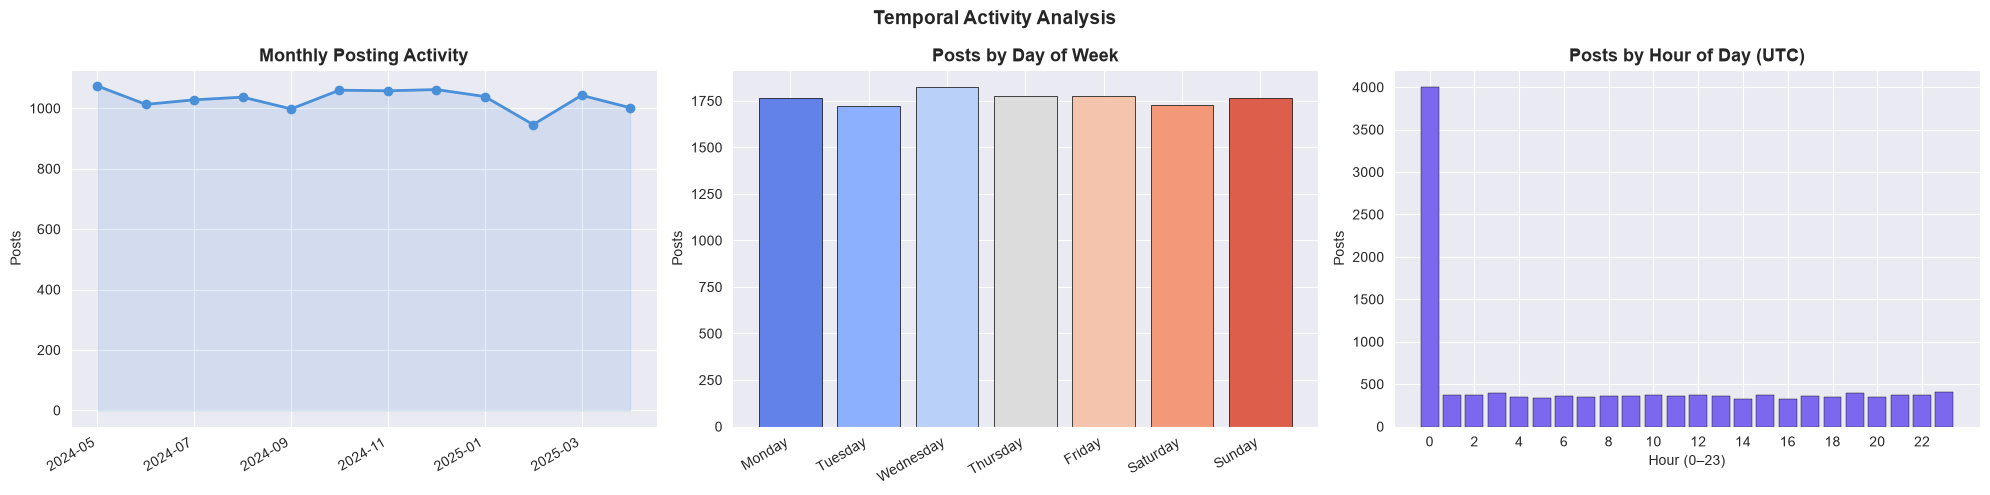

In [18]:
df_time = df_posts.dropna(subset=['timestamp']).copy()
df_time['year_month']  = df_time['timestamp'].dt.to_period('M')
df_time['day_of_week'] = df_time['timestamp'].dt.day_name()
df_time['hour_of_day'] = df_time['timestamp'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

monthly = df_time.groupby('year_month').size().reset_index(name='posts')
monthly['ym_str'] = monthly['year_month'].astype(str)
axes[0].plot(monthly['ym_str'], monthly['posts'], marker='o', linewidth=2, color='#4A90D9')
axes[0].fill_between(range(len(monthly)), monthly['posts'], alpha=0.15, color='#4A90D9')
step = max(1, len(monthly)//6)
axes[0].set_xticks(range(0, len(monthly), step))
axes[0].set_xticklabels(monthly['ym_str'].iloc[::step], rotation=30, ha='right')
axes[0].set_title('Monthly Posting Activity')
axes[0].set_ylabel('Posts')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df_time['day_of_week'].value_counts().reindex(dow_order)
axes[1].bar(dow_order, dow_counts.values, color=sns.color_palette('coolwarm', 7), edgecolor='black', linewidth=0.5)
axes[1].set_title('Posts by Day of Week')
axes[1].set_xticklabels(dow_order, rotation=30, ha='right')
axes[1].set_ylabel('Posts')

hour_counts = df_time['hour_of_day'].value_counts().sort_index()
axes[2].bar(hour_counts.index, hour_counts.values, color='#7B68EE', edgecolor='black', linewidth=0.3)
axes[2].set_title('Posts by Hour of Day (UTC)')
axes[2].set_xlabel('Hour (0–23)')
axes[2].set_ylabel('Posts')
axes[2].set_xticks(range(0, 24, 2))

plt.suptitle('Temporal Activity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_03_temporal_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


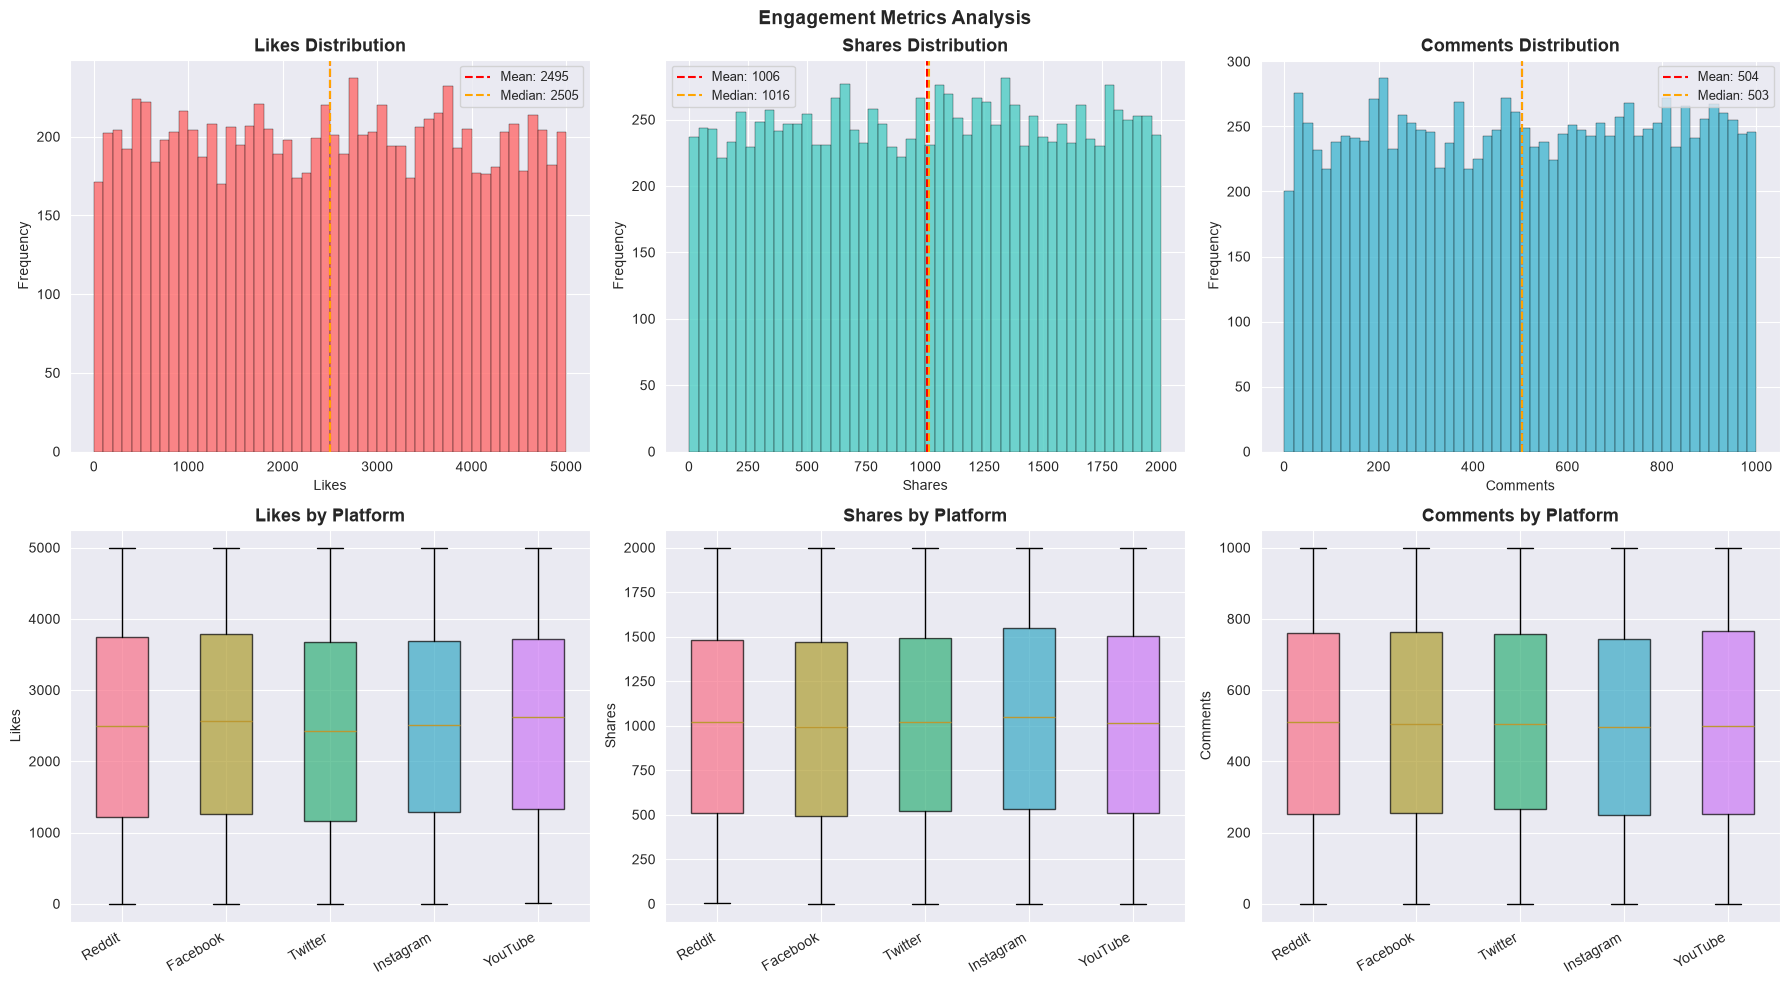

Descriptive Statistics:


,likes,shares,comments
count,9977.0,12360.0,12360.0
mean,2494.62173,1005.867557,504.081958
std,1437.920657,574.734542,288.796752
min,0.0,0.0,0.0
25%,1241.0,509.0,252.0
50%,2505.0,1016.0,503.0
75%,3725.0,1499.0,755.0
max,5000.0,2000.0,1000.0


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['likes', 'shares', 'comments']
colors_m = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    data = df_posts[metric].dropna().astype(float)

    axes[0, i].hist(data, bins=50, color=color, edgecolor='black', linewidth=0.3, alpha=0.8)
    axes[0, i].set_title(f'{metric.capitalize()} Distribution')
    axes[0, i].set_xlabel(metric.capitalize())
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].axvline(float(data.mean()), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {float(data.mean()):.0f}')
    axes[0, i].axvline(float(data.median()), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {float(data.median()):.0f}')
    axes[0, i].legend(fontsize=9)

    plats = df_posts['platform'].dropna().unique()
    platform_data   = [df_posts[df_posts['platform'] == p][metric].dropna().astype(float) for p in plats]
    bp = axes[1, i].boxplot(platform_data, label=plats, patch_artist=True)
    for patch, c in zip(bp['boxes'], sns.color_palette('husl', len(plats))):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1, i].set_title(f'{metric.capitalize()} by Platform')
    axes[1, i].set_xticklabels(plats, rotation=30, ha='right')
    axes[1, i].set_ylabel(metric.capitalize())

plt.suptitle('Engagement Metrics Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_04_engagement_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("Descriptive Statistics:")
display(df_posts[['likes','shares','comments']].describe())


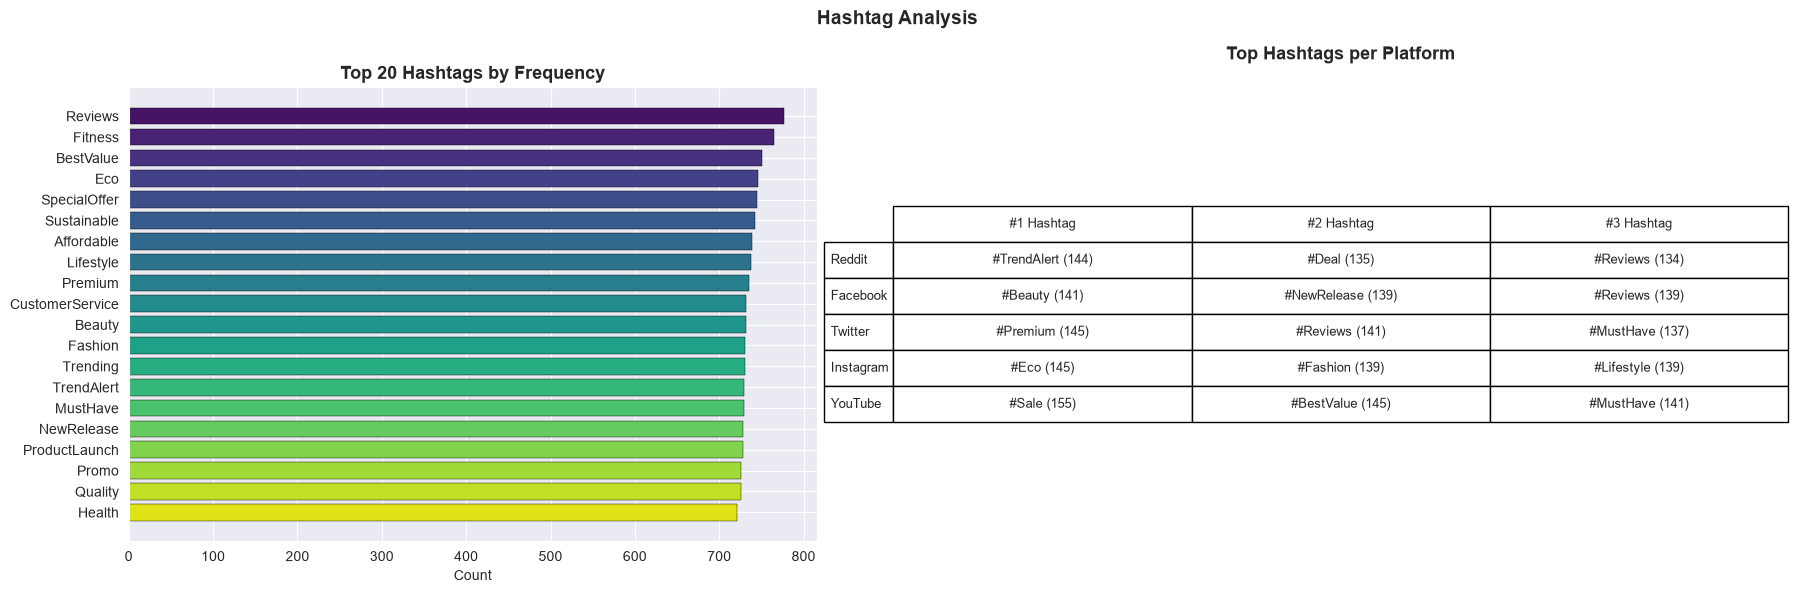

Total unique hashtags : 56
Total hashtag uses    : 21157


In [21]:
all_tags = []
for text in df_posts['text_content'].dropna():
    all_tags.extend(re.findall(r'#(\w+)', str(text)))

tag_counts = Counter(all_tags)
top20 = pd.DataFrame(tag_counts.most_common(20), columns=['hashtag','count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_ht = sns.color_palette('viridis', 20)
axes[0].barh(top20['hashtag'][::-1], top20['count'][::-1], color=colors_ht[::-1], edgecolor='black', linewidth=0.3)
axes[0].set_title('Top 20 Hashtags by Frequency')
axes[0].set_xlabel('Count')

ph_data = {}
for plat in df_posts['platform'].dropna().unique():
    texts = df_posts[df_posts['platform'] == plat]['text_content'].dropna()
    tags = []
    for t in texts: tags.extend(re.findall(r'#(\w+)', str(t)))
    if tags:
        ph_data[plat] = [f"#{t[0]} ({t[1]})" for t in Counter(tags).most_common(3)]

ph_df = pd.DataFrame(ph_data).T
ph_df.columns = ['#1 Hashtag', '#2 Hashtag', '#3 Hashtag']
axes[1].axis('off')
tbl = axes[1].table(cellText=ph_df.values, rowLabels=ph_df.index,
                    colLabels=ph_df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 2.2)
axes[1].set_title('Top Hashtags per Platform', fontweight='bold', pad=20)

plt.suptitle(' Hashtag Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_05_hashtag_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique hashtags : {len(tag_counts)}")
print(f"Total hashtag uses    : {sum(tag_counts.values())}")


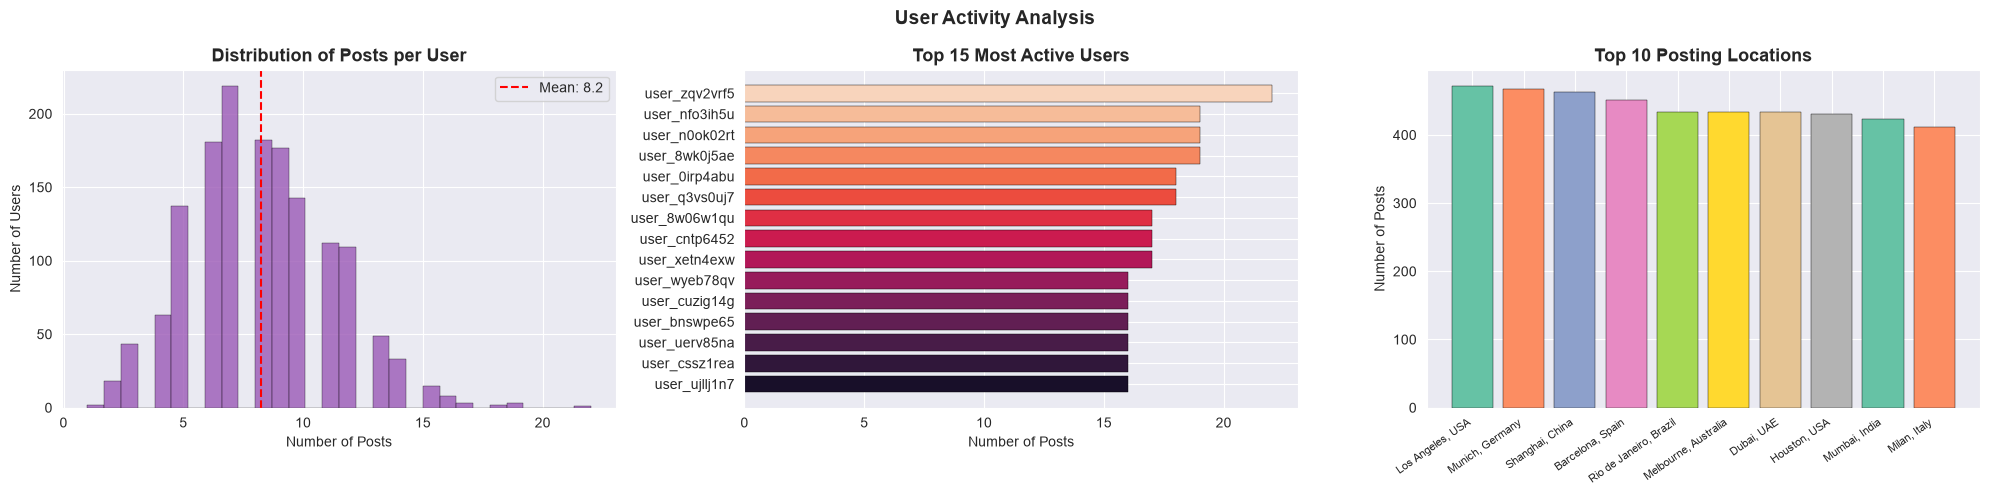

Unique users in posts : 1500
Mean posts/user       : 8.2
Max posts by one user : 22


In [22]:
user_post_counts = df_posts['user_id'].value_counts()
merged = df_posts.merge(df_users[['user_id','location']], on='user_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(user_post_counts.values, bins=30, color='#9B59B6', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0].set_title('Distribution of Posts per User')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(user_post_counts.mean(), color='red', linestyle='--', label=f'Mean: {user_post_counts.mean():.1f}')
axes[0].legend()

top_users = user_post_counts.head(15)
axes[1].barh(top_users.index[::-1], top_users.values[::-1],
             color=sns.color_palette('rocket', 15), edgecolor='black', linewidth=0.3)
axes[1].set_title('Top 15 Most Active Users')
axes[1].set_xlabel('Number of Posts')

top_locs = merged['location'].value_counts().head(10)
axes[2].bar(range(len(top_locs)), top_locs.values, color=sns.color_palette('Set2', 10), edgecolor='black', linewidth=0.3)
axes[2].set_xticks(range(len(top_locs)))
axes[2].set_xticklabels(top_locs.index, rotation=35, ha='right', fontsize=8)
axes[2].set_title('Top 10 Posting Locations')
axes[2].set_ylabel('Number of Posts')

plt.suptitle('User Activity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_06_user_activity.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique users in posts : {df_posts['user_id'].nunique()}")
print(f"Mean posts/user       : {user_post_counts.mean():.1f}")
print(f"Max posts by one user : {user_post_counts.max()}")


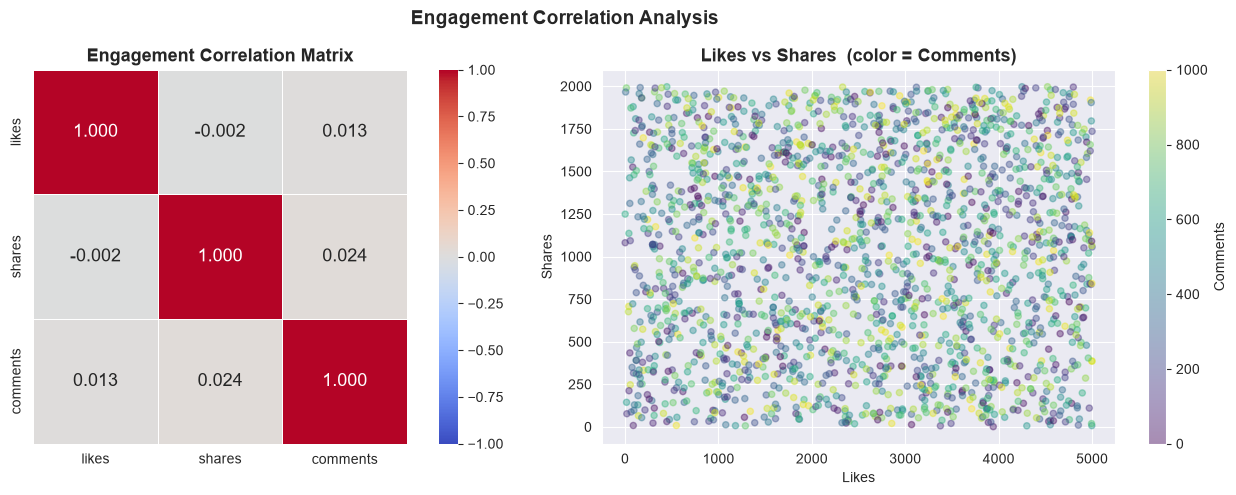

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numeric_df = df_posts[['likes','shares','comments']].astype(float)
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 13})
axes[0].set_title('Engagement Correlation Matrix')

sample = numeric_df.dropna().sample(min(2000, len(numeric_df)), random_state=42)
sc = axes[1].scatter(sample['likes'], sample['shares'],
                     c=sample['comments'], cmap='viridis', alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[1], label='Comments')
axes[1].set_title('Likes vs Shares  (color = Comments)')
axes[1].set_xlabel('Likes')
axes[1].set_ylabel('Shares')

plt.suptitle('Engagement Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_07_correlation.png", dpi=150, bbox_inches='tight')
plt.show()


---IQR-Based Outlier Detection-----


LIKES
  Q1=1241  Q3=3725  IQR=2484
  Bounds  : [0, 7451]
  Outliers: 0 (0.00%)

SHARES
  Q1=509  Q3=1499  IQR=990
  Bounds  : [0, 2984]
  Outliers: 0 (0.00%)

COMMENTS
  Q1=252  Q3=755  IQR=503
  Bounds  : [0, 1510]
  Outliers: 0 (0.00%)


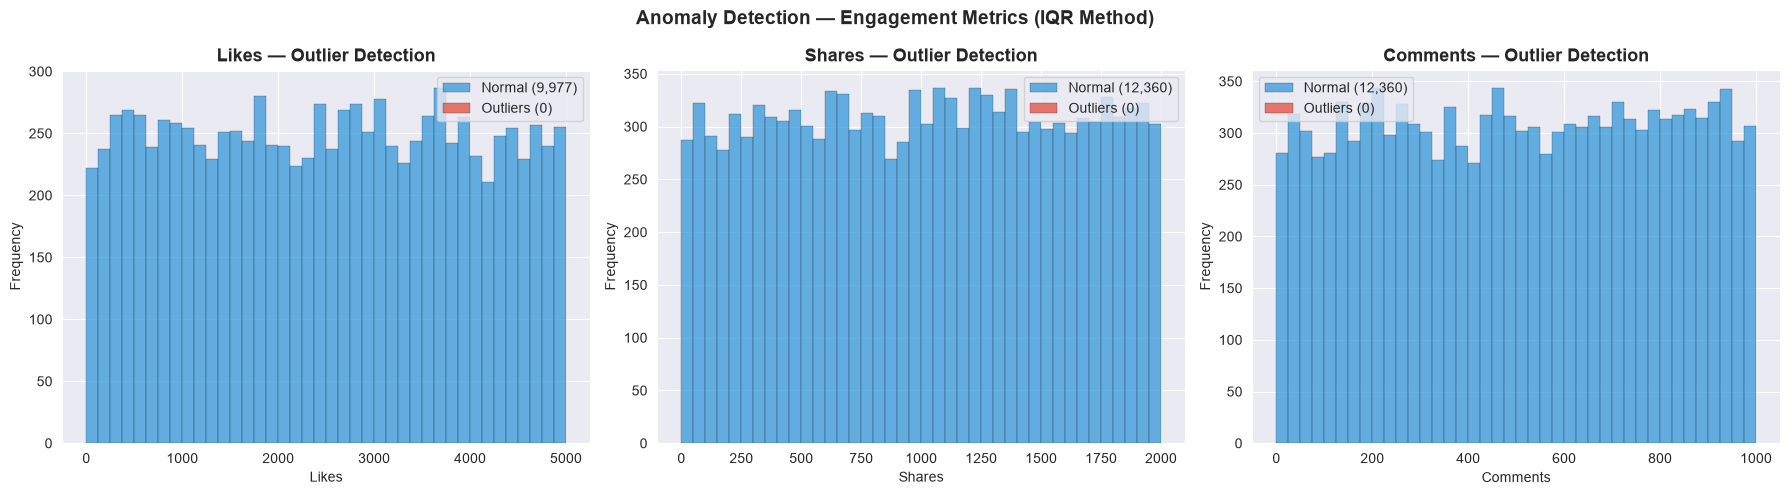

In [25]:

print("---IQR-Based Outlier Detection-----\n")
for col in ['likes', 'shares', 'comments']:
    data = df_posts[col].dropna().astype(float)
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = max(0, Q1 - 1.5*IQR), Q3 + 1.5*IQR
    mask = (df_posts[col].astype(float) < lower) | (df_posts[col].astype(float) > upper)
    df_posts[f'{col}_is_outlier'] = mask
    print(f"\n{col.upper()}")
    print(f"  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}")
    print(f"  Bounds  : [{lower:.0f}, {upper:.0f}]")
    print(f"  Outliers: {mask.sum()} ({mask.sum()/len(df_posts)*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['likes','shares','comments']):
    data = df_posts[col].dropna().astype(float)
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75); IQR = Q3 - Q1
    normal   = data[(data >= Q1-1.5*IQR) & (data <= Q3+1.5*IQR)]
    outliers = data[(data <  Q1-1.5*IQR) | (data >  Q3+1.5*IQR)]
    axes[i].hist(normal, bins=40, color='#3498DB', alpha=0.75, label=f'Normal ({len(normal):,})', edgecolor='black', linewidth=0.2)
    axes[i].hist(outliers, bins=40, color='#E74C3C', alpha=0.75, label=f'Outliers ({len(outliers):,})', edgecolor='black', linewidth=0.2)
    axes[i].set_title(f'{col.capitalize()} — Outlier Detection')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Anomaly Detection — Engagement Metrics (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"d:\project\DataScience\Data Vortex\plot_08_anomaly_detection.png", dpi=150, bbox_inches='tight')
plt.show()


In [26]:
posts_uids = set(df_posts['user_id'].dropna().unique())
users_uids = set(df_users['user_id'].unique())

orphan_ids    = posts_uids - users_uids   
inactive_uids = users_uids - posts_uids   

print(f"Unique users in posts dataset : {len(posts_uids):,}")
print(f"Unique users in users dataset : {len(users_uids):,}")
print(f"Orphan user_ids (posts only)  : {len(orphan_ids):,}  ← flagged, retained")
print(f"Users with zero posts         : {len(inactive_uids):,}")

df_posts['user_in_registry'] = df_posts['user_id'].isin(users_uids)
orphan_posts = (~df_posts['user_in_registry']).sum()
print(f"\nPosts with unregistered user_id: {orphan_posts} ({orphan_posts/len(df_posts)*100:.1f}%)")
print("→ These rows are retained. User may be deleted or from an external source.")
if orphan_ids:
    print(f"\nSample orphan IDs: {list(orphan_ids)[:8]}")


Unique users in posts dataset : 1,500
Unique users in users dataset : 1,500
Orphan user_ids (posts only)  : 0  ← flagged, retained
Users with zero posts         : 0

Posts with unregistered user_id: 0 (0.0%)
→ These rows are retained. User may be deleted or from an external source.


In [27]:
df_posts_export = df_posts.copy()
df_posts_export['timestamp'] = df_posts_export['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')

df_users.to_csv(OUT_USERS, index=False, encoding='utf-8-sig')
df_posts_export.to_csv(OUT_POSTS, index=False, encoding='utf-8-sig')

print("EXPORT COMPLETE")
print(f"\n  Users cleaned  → {OUT_USERS}")
print(f"  Rows: {len(df_users)}  |  Cols: {df_users.shape[1]}")
print(f"\n  Posts cleaned  → {OUT_POSTS}")
print(f"  Rows: {len(df_posts_export)}  |  Cols: {df_posts_export.shape[1]}")

display(df_users.head(3))
display(df_posts_export[['post_id','user_id','platform','timestamp','likes','shares','comments']].head(3))


EXPORT COMPLETE

  Users cleaned  → d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Users_Cleaned.csv
  Rows: 1500  |  Cols: 5

  Posts cleaned  → d:\project\DataScience\Data Vortex\Dataset\Social_Engine_Posts_Cleaned.csv
  Rows: 12360  |  Cols: 12


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842


,post_id,user_id,platform,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,2024-09-25T00:00:00Z,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,2024-08-01T16:14:00Z,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,2025-04-13T20:12:18Z,<NA>,1410,839


In [30]:

print(" ------ DATA VORTEX - PHASE 1 FINAL CLEANING REPORT -------")

print(f"""
Social_Engine_Users.csv
  Original rows        : {len(df_users_raw)}
  Cleaned rows         : {len(df_users)}
  Duplicates removed   : {len(df_users_raw) - len(df_users)}
  Missing remaining    : {df_users.isnull().sum().sum()}

Social_Engine_Posts_Corrupted.csv
  Original rows        : {len(df_posts_raw)}
  Cleaned rows         : {len(df_posts)}  (all rows retained, no data dropped)
  Original columns     : {df_posts_raw.shape[1]}
  Cleaned columns      : {df_posts.shape[1]}

Fixes Applied
  - NULL strings unified to NaN
  - UTF-8 encoding artifacts corrected (e.g. corrupted accented characters)
  - HTML entities decoded (e.g. &amp; restored to &)
  - HTML tags removed from text content
  - Embedded newlines collapsed in text fields
  - Timestamps normalized to UTC ISO 8601 format
  - Negative likes set to NaN and flagged
  - Numeric fields cast to nullable integer type
  - Platform values standardized to known categories
  - Statistical outliers flagged using IQR method
  - Cross-dataset user ID integrity checked and flagged

Assumptions Made
  1. Unix timestamps are treated as UTC, which is standard for web APIs
  2. Ambiguous dates are interpreted as DD-MM-YYYY based on European user majority
  3. Negative likes are treated as data entry errors, set to NaN, row retained
  4. The string NULL is treated as equivalent to a missing value
  5. HTML content is a rendering artifact, decoded not fabricated
  6. Encoding artifacts fixed using a known character substitution table
  7. Rows with empty text content are retained as NaN, nothing fabricated
  8. Posts with unregistered user IDs are flagged in a column and retained
""")

print("Charts saved:")
for i, name in enumerate(['missing_values', 'platform_distribution', 'temporal_analysis',
                           'engagement_analysis', 'hashtag_analysis', 'user_activity',
                           'correlation', 'anomaly_detection'], 1):
    print(f"  plot_0{i}_{name}.png")



 ------ DATA VORTEX - PHASE 1 FINAL CLEANING REPORT -------

Social_Engine_Users.csv
  Original rows        : 1500
  Cleaned rows         : 1500
  Duplicates removed   : 0
  Missing remaining    : 0

Social_Engine_Posts_Corrupted.csv
  Original rows        : 12360
  Cleaned rows         : 12360  (all rows retained, no data dropped)
  Original columns     : 8
  Cleaned columns      : 12

Fixes Applied
  - NULL strings unified to NaN
  - UTF-8 encoding artifacts corrected (e.g. corrupted accented characters)
  - HTML entities decoded (e.g. &amp; restored to &)
  - HTML tags removed from text content
  - Embedded newlines collapsed in text fields
  - Timestamps normalized to UTC ISO 8601 format
  - Negative likes set to NaN and flagged
  - Numeric fields cast to nullable integer type
  - Platform values standardized to known categories
  - Statistical outliers flagged using IQR method
  - Cross-dataset user ID integrity checked and flagged

Assumptions Made
  1. Unix timestamps are treate